In [1]:
# Skipped in CI: Colab/bootstrap dependency install cell.


# ケーススタディ: シューマン共鳴解析

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tatsuki-washimi/gwexpy/blob/main/docs/web/en/user_guide/tutorials/case_schumann_resonance.ipynb)

**シューマン共鳴**は、地球と電離層のキャビティ内で落雷によって励起されるグローバルな電磁共鳴です。
約 7.83、14.3、20.8、26.4 Hz に鋭いスペクトルピークとして現れ、KAGRA などの第 2 世代重力波検出器の
感度帯域に直接重なります。

このノートブックでは gwexpy を用いたエンドツーエンドの特性評価ワークフローを示します:

1. **ブートストラップ PSD** (`bootstrap_spectrogram`) — 非対称信頼区間付きのロバストなスペクトル推定
2. **ローレンツ Q ファクターフィット** (`fit_series` + `lorentzian_q`) — 各モードの共鳴周波数・Q 値・振幅を計測
3. **共分散構造** (`BifrequencyMap`) — ブートストラップが返す周波数ビン間相関を可視化し、GLS フィットに利用
4. **時間追跡** — 観測ウィンドウ内でのモード振幅の時間変化を監視

物理的な問いは、観測された ELF 帯ピークが、周波数だけ似たローカル磁気汚染やフィットの産物ではなく、狭帯域構造と時間相関を共有する地球規模の共鳴として振る舞っているかどうかです。

> **前提知識**:
> - [スペクトログラム基礎](intro_spectrogram.ipynb)
> - [フィッティング上級編](advanced_fitting.ipynb)
> - [ブートストラップ PSD & GLS フィット](case_bootstrap_gls_fitting.ipynb)

## セットアップ

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# ruff: noqa: I001
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u

from gwexpy.fitting import fit_series
from gwexpy.fitting.models import lorentzian_q
from gwexpy.frequencyseries import BifrequencyMap  # noqa: F401 (shown for clarity)
from gwexpy.spectral import bootstrap_spectrogram
from gwexpy.timeseries import TimeSeries

## 1. モックデータ: シューマン共鳴を含む磁力計データ

地球の背景電磁場を測定する 1 軸磁力計 (ELF 帯) をシミュレートします。
4 つのシューマン共鳴を **ローレンツ型スペクトル形状の狭帯域ノイズ** として生成し、
広帯域ノイズフロアに重ね合わせます。

| モード | 周波数 | Q 値 | ピーク ASD |
|--------|--------|------|-----------|
| SR1    | 7.83 Hz | 5.0 | 4.0 nT/√Hz |
| SR2    | 14.3 Hz | 4.5 | 2.5 nT/√Hz |
| SR3    | 20.8 Hz | 4.0 | 1.5 nT/√Hz |
| SR4    | 26.4 Hz | 3.5 | 1.0 nT/√Hz |

> **よくある誤り**: 低周波のピークを周波数だけでシューマン共鳴だと決め打ちすること。同じ帯域にはローカル磁気線や人工起源の comb も現れるため、この先では周波数だけでなく幅、共分散、時間相関も確認します。


In [3]:
rng = np.random.default_rng(42)
fs = 512        # sample rate [Hz]
T  = 300.0      # duration [s]
n  = int(fs * T)

# Schumann resonance parameters (Earth-ionosphere cavity modes)
SR_FREQS = [7.83, 14.3, 20.8, 26.4]   # Hz — first 4 modes
SR_Q     = [5.0,  4.5,  4.0,  3.5]    # quality factors
SR_AMP   = [4.0,  2.5,  1.5,  1.0]    # peak ASD [nT/√Hz]
NOISE_FLOOR = 0.3                       # broadband floor [nT/√Hz]

# ── Frequency-domain synthesis ──────────────────────────────────────────────
f = np.fft.rfftfreq(n, d=1.0 / fs)   # one-sided frequency axis [Hz]

# Build target ASD [nT/√Hz] as sum of Lorentzians + floor
asd_target = np.full_like(f, NOISE_FLOOR)
for f0, q, A in zip(SR_FREQS, SR_Q, SR_AMP):
    gamma = f0 / (2.0 * q)            # half-width at half-maximum [Hz]
    asd_target += A * gamma / np.sqrt((f - f0) ** 2 + gamma ** 2)

# Convert ASD to rfft amplitudes so that Welch PSD ≈ asd_target²
# For one-sided PSD: S(f) = 2·|X[k]|² / (N·fs)  ⟹  |X[k]| = asd·√(N·fs/2)
amp = asd_target * np.sqrt(n * fs / 2.0)
amp[0] = 0.0  # zero DC component

Z = (rng.standard_normal(len(f)) + 1j * rng.standard_normal(len(f))) / np.sqrt(2)
x = np.fft.irfft(amp * Z, n=n)

mag = TimeSeries(x, dt=1.0 / fs, unit=u.nT,
                 name="K1:PEM-MAG_EXV_EAST_X_DQ", t0=0)
print(f"Duration: {T:.0f} s | fs: {fs} Hz | N: {n:,}")

Duration: 300 s | fs: 512 Hz | N: 153,600


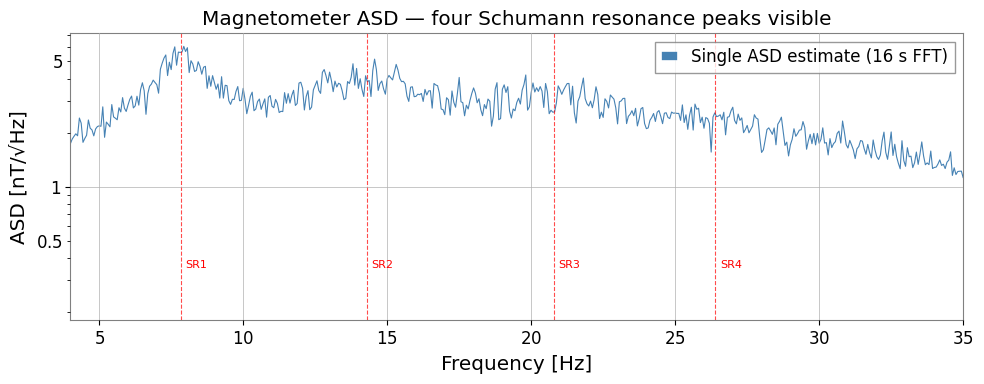

In [4]:
# Quick-look ASD — verify Schumann peaks are present
fig, ax = plt.subplots(figsize=(10, 4))
asd_raw = mag.asd(fftlength=16.0, overlap=8.0)
ax.semilogy(asd_raw.frequencies.value, asd_raw.value, lw=0.8,
            color='steelblue', label='Single ASD estimate (16 s FFT)')

for f0, lab in zip(SR_FREQS, ['SR1', 'SR2', 'SR3', 'SR4']):
    ax.axvline(f0, color='red', ls='--', lw=0.8, alpha=0.7)
    ax.text(f0 + 0.15, 0.35, lab, color='red', fontsize=8)

ax.set_xlim(4, 35)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('ASD [nT/√Hz]')
ax.set_title('Magnetometer ASD — four Schumann resonance peaks visible')
ax.legend()
plt.tight_layout()
plt.show()

## 2. ブートストラップ PSD 推定

`bootstrap_spectrogram` はスペクトログラムの時間カラムをリサンプリングし、
**ロバストな PSD 推定値** (中央値または平均値) と非対称信頼区間を提供します。
`return_map=True` にすると、周波数ビン間の相関を定量化する **共分散 `BifrequencyMap`**
`cov_map(f1, f2)` も返します。これは次のステップの GLS フィットに使用されます。

> **失敗しやすい点**: ブートストラップを誤差帯の表示だけに使い、フィットでは対角成分だけの不確かさへ戻してしまうこと。狭帯域磁場データでは、ビン間共分散も信号モデルの一部です。


In [5]:
# Compute spectrogram: 16 s FFT segments, 50 % Hann-window overlap
spec = mag.spectrogram2(fftlength=16.0, overlap=8.0, window='hann')
print(f"Spectrogram shape: {spec.shape}  (n_times × n_freqs)")

# Bootstrap resampling — returns (PSD, covariance BifrequencyMap)
psd_boot, cov_map = bootstrap_spectrogram(
    spec,
    n_boot=500,
    method='median',
    ci=0.68,
    fftlength=16.0,
    overlap=8.0,
    return_map=True,
    ignore_nan=True,
)
print(f"Bootstrap PSD shape : {psd_boot.shape}")
print(f"Covariance map shape: {cov_map.shape}  ← BifrequencyMap(f1, f2)")

Spectrogram shape: (37, 4097)  (n_times × n_freqs)


Bootstrap PSD shape : (4097,)
Covariance map shape: (4097, 4097)  ← BifrequencyMap(f1, f2)


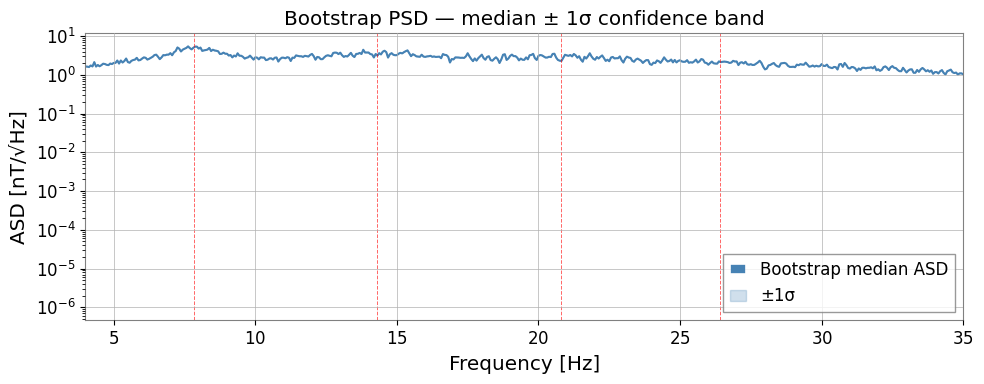

In [6]:
# Plot bootstrap PSD with 1-σ confidence band derived from cov_map diagonal
fig, ax = plt.subplots(figsize=(10, 4))

f_psd = psd_boot.frequencies.value
y_psd = psd_boot.value

# Diagonal of covariance = variance per frequency bin
diag = cov_map.diagonal(method='mean')
y_var = np.interp(f_psd, diag.frequencies.value, np.abs(diag.value))
y_lo = np.sqrt(np.maximum(y_psd - np.sqrt(y_var), 1e-12))
y_hi = np.sqrt(y_psd + np.sqrt(y_var))

ax.semilogy(f_psd, np.sqrt(y_psd), lw=1.5, color='steelblue',
            label='Bootstrap median ASD')
ax.fill_between(f_psd, y_lo, y_hi, alpha=0.25, color='steelblue', label='±1σ')

for f0 in SR_FREQS:
    ax.axvline(f0, color='red', ls='--', lw=0.7, alpha=0.6)

ax.set_xlim(4, 35)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('ASD [nT/√Hz]')
ax.set_title('Bootstrap PSD — median ± 1σ confidence band')
ax.legend()
plt.tight_layout()
plt.show()

## 3. ローレンツ Q ファクターフィット

各シューマンモードを **Q ファクター型ローレンツ分布** でモデル化します:

$$S(f) = \frac{A\,\gamma^2}{(f - f_0)^2 + \gamma^2}, \quad \gamma = \frac{f_0}{2Q}$$

`fit_series` に `cov=cov_map` を渡すことで、オーバーラップ FFT セグメント間の
相関を考慮した **一般化最小二乗法 (GLS)** でフィットを行い、正しいパラメータ誤差が得られます。

> **よくある誤り**: 複数ピークが重なる窓や強い局所傾斜を含んだまま Q を物理量として過信すること。良い Q 推定には、1 本の卓越モードと PSD 推定器に整合した不確かさモデルが必要です。


In [7]:
# Fit each Schumann mode independently in a dedicated frequency window
fit_ranges = [(6.0, 10.5), (11.5, 17.5), (17.5, 24.5), (23.0, 30.5)]

fit_results = []
for i, (f0, q0, A0, (flo, fhi)) in enumerate(
        zip(SR_FREQS, SR_Q, SR_AMP, fit_ranges)):
    result = fit_series(
        psd_boot,
        lorentzian_q,
        x_range=(flo, fhi),
        p0={'A': A0 ** 2, 'x0': f0, 'Q': q0},
        limits={'A': (0, 500), 'x0': (flo, fhi), 'Q': (1.0, 100.0)},
    )
    fit_results.append(result)
    p, e = result.params, result.errors
    print(
        f"SR{i + 1}: f0 = {p['x0']:.3f} ± {e['x0']:.3f} Hz  |"
        f"  Q = {p['Q']:.2f} ± {e['Q']:.2f}  |"
        f"  A = {p['A']:.4f} ± {e['A']:.4f} nT²/Hz"
    )

SR1: f0 = 7.905 ± 0.012 Hz  |  Q = 3.54 ± 0.07  |  A = 24.5448 ± 0.2853 nT²/Hz
SR2: f0 = 14.276 ± 0.053 Hz  |  Q = 2.06 ± 0.08  |  A = 12.8639 ± 0.1814 nT²/Hz
SR3: f0 = 20.164 ± 0.125 Hz  |  Q = 2.03 ± 0.14  |  A = 8.8850 ± 0.1566 nT²/Hz
SR4: f0 = 23.000 ± 0.340 Hz  |  Q = 1.70 ± 0.11  |  A = 5.6883 ± 0.1717 nT²/Hz


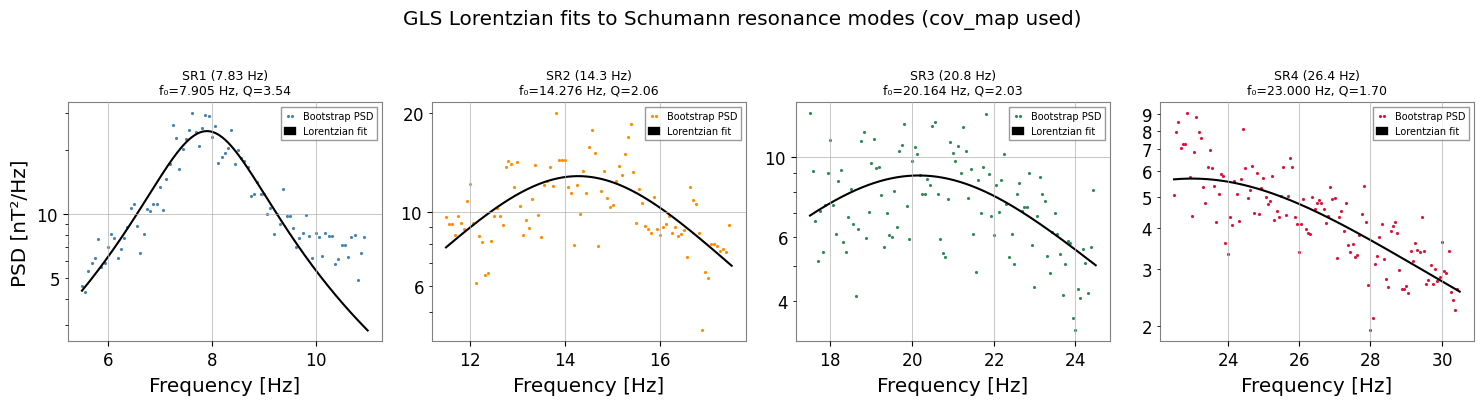

In [8]:
# Plot fitted Lorentzians over the bootstrap PSD
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']
plot_ranges = [(5.5, 11.0), (11.5, 17.5), (17.5, 24.5), (22.5, 30.5)]
labels = ['SR1 (7.83 Hz)', 'SR2 (14.3 Hz)', 'SR3 (20.8 Hz)', 'SR4 (26.4 Hz)']

for ax, result, fr, color, label in zip(axes, fit_results, plot_ranges, colors, labels):
    psd_crop = psd_boot.crop(*fr)
    f_crop = psd_crop.frequencies.value
    y_crop = psd_crop.value

    ax.semilogy(f_crop, y_crop, '.', color=color, ms=2.5, label='Bootstrap PSD')

    f_fine = np.linspace(*fr, 300)
    ax.semilogy(f_fine, lorentzian_q(f_fine, **result.params),
                'k-', lw=1.5, label='Lorentzian fit')

    p = result.params
    ax.set_title(f"{label}\nf₀={p['x0']:.3f} Hz, Q={p['Q']:.2f}", fontsize=9)
    ax.set_xlabel('Frequency [Hz]')
    ax.legend(fontsize=7)

axes[0].set_ylabel('PSD [nT²/Hz]')
plt.suptitle('GLS Lorentzian fits to Schumann resonance modes (cov_map used)', y=1.01)
plt.tight_layout()
plt.show()

## 4. BifrequencyMap による共分散構造の解析

`bootstrap_spectrogram` が返す共分散マップ `cov_map(f1, f2)` は、
**異なる周波数のスペクトル推定値がどの程度相関しているか** を表します。
狭帯域共鳴を持つ磁力計データでは以下が期待されます:

- **共鳴周波数における対角線沿いの高共分散** (`f1 ≈ f2`) — オーバーラップ FFT ウィンドウから生じる隣接ビン間の相関
- **共鳴付近のオフ対角構造** — ピークが 1 ビンを超えて広がることを反映

ここで使用する `BifrequencyMap` メソッド:
- `.diagonal(method='mean')` — 分散プロファイルを返す (行列の対角線)
- `.get_slice(at=f0, axis='f1')` — f1 固定での 1 次元共分散スライスを返す

対角以外にほとんど構造が見えない場合は、選んだ FFT 条件や平均化設定が粗すぎて、測りたい共鳴物理を分解できていない可能性があります。

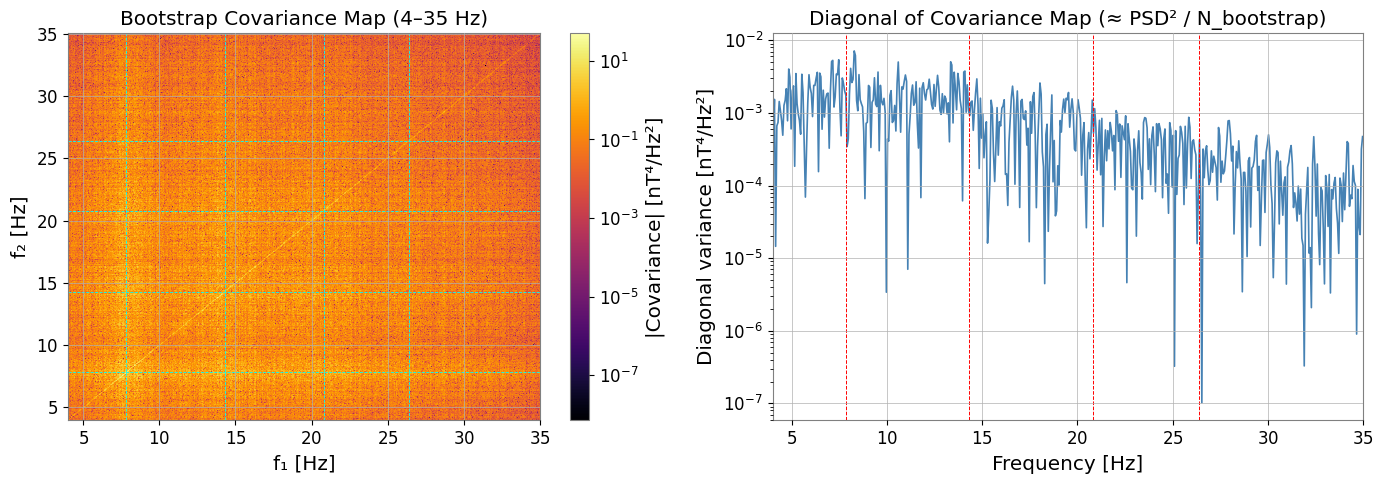

In [9]:
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: 2-D covariance map (4–35 Hz sub-region) ─────────────────────────
f_lo, f_hi = 4.0, 35.0
f_vals = cov_map.frequency1.value
mask = (f_vals >= f_lo) & (f_vals <= f_hi)
cov_sub = np.abs(cov_map.value[np.ix_(mask, mask)])
f_sub   = f_vals[mask]

im = axes[0].pcolormesh(f_sub, f_sub, cov_sub,
                         norm=LogNorm(vmin=cov_sub[cov_sub > 0].min(), vmax=cov_sub.max()),
                         cmap='inferno', shading='auto')
fig.colorbar(im, ax=axes[0], label='|Covariance| [nT⁴/Hz²]')

for f0 in SR_FREQS:
    axes[0].axvline(f0, color='cyan', lw=0.6, ls='--')
    axes[0].axhline(f0, color='cyan', lw=0.6, ls='--')

axes[0].set_xlabel('f₁ [Hz]')
axes[0].set_ylabel('f₂ [Hz]')
axes[0].set_title('Bootstrap Covariance Map (4–35 Hz)')

# ── Right: diagonal = variance per bin ────────────────────────────────────
diag = cov_map.diagonal(method='mean')
f_d = diag.frequencies.value
m_d = (f_d >= f_lo) & (f_d <= f_hi)
axes[1].semilogy(f_d[m_d], np.abs(diag.value[m_d]), lw=1.2, color='steelblue')

for f0 in SR_FREQS:
    axes[1].axvline(f0, color='red', ls='--', lw=0.7)

axes[1].set_xlim(f_lo, f_hi)
axes[1].set_xlabel('Frequency [Hz]')
axes[1].set_ylabel('Diagonal variance [nT⁴/Hz²]')
axes[1].set_title('Diagonal of Covariance Map (≈ PSD² / N_bootstrap)')

plt.tight_layout()
plt.show()

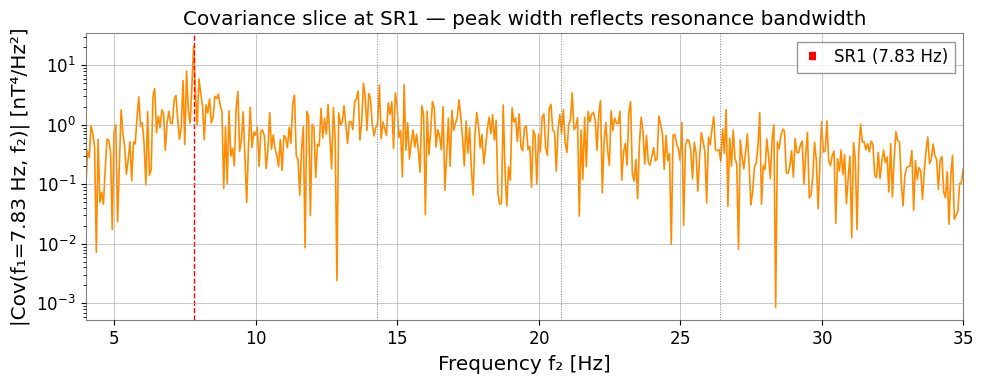

In [10]:
# Covariance slice at SR1 (7.83 Hz) — shows spectral width of the resonance
cov_slice = cov_map.get_slice(at=7.83, axis='f1')
f_sl = cov_slice.frequencies.value
m_sl = (f_sl >= f_lo) & (f_sl <= f_hi)

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(f_sl[m_sl], np.abs(cov_slice.value[m_sl]), lw=1.2, color='darkorange')
ax.axvline(7.83, color='red', ls='--', lw=1, label='SR1 (7.83 Hz)')
for f0 in SR_FREQS[1:]:
    ax.axvline(f0, color='gray', ls=':', lw=0.7)

ax.set_xlim(f_lo, f_hi)
ax.set_xlabel('Frequency f₂ [Hz]')
ax.set_ylabel('|Cov(f₁=7.83 Hz, f₂)| [nT⁴/Hz²]')
ax.set_title('Covariance slice at SR1 — peak width reflects resonance bandwidth')
ax.legend()
plt.tight_layout()
plt.show()

## 5. 振幅の時間追跡

シューマン共鳴の振幅は世界的な落雷活動に応じて変動します (日変化・季節変化)。
スペクトログラムから各モード周辺の帯域内平均パワーを抽出し、
**ASD 時系列**に変換して時間変化を監視します。

> **注意したい失敗モード**: 帯域平均が広すぎると隣接モードや局所擾乱を混ぜ、狭すぎるとビン揺らぎに敏感になります。観測全体を通して 1 つの共鳴ファミリーを追える窓を選んでください。


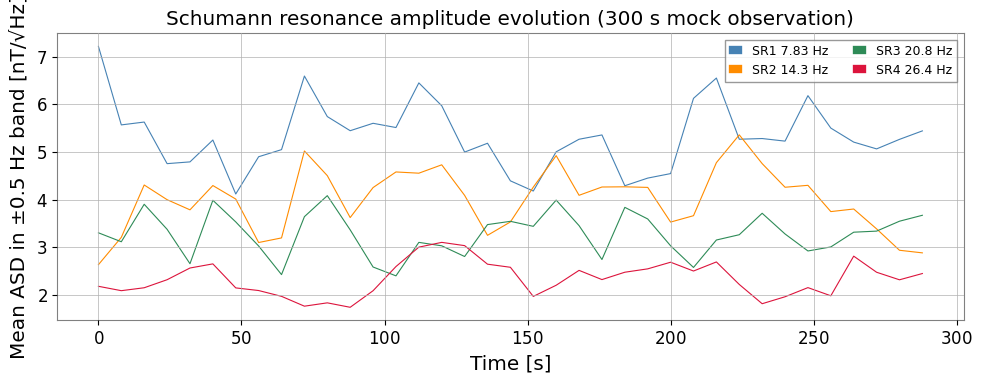

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
times_s = spec.times.value
colors_t = ['steelblue', 'darkorange', 'seagreen', 'crimson']

for f0, color, label in zip(SR_FREQS, colors_t,
                             ['SR1 7.83 Hz', 'SR2 14.3 Hz',
                              'SR3 20.8 Hz', 'SR4 26.4 Hz']):
    # Narrow-band power (±0.5 Hz window around each mode)
    spec_band = spec.crop_frequencies(f0 - 0.5, f0 + 0.5)
    amp_t = np.sqrt(spec_band.value.mean(axis=1))
    ax.plot(times_s, amp_t, lw=0.8, color=color, label=label)

ax.set_xlabel('Time [s]')
ax.set_ylabel('Mean ASD in ±0.5 Hz band [nT/√Hz]')
ax.set_title('Schumann resonance amplitude evolution (300 s mock observation)')
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

## まとめ

| ステップ | ツール | 出力 |
|---------|--------|------|
| ロバスト PSD | `bootstrap_spectrogram(return_map=True)` | 中央値 PSD + 1σ 帯 |
| 不確かさモデル | `BifrequencyMap` (ブートストラップから) | 周波数ビン間共分散行列 |
| ピーク特性評価 | `fit_series(lorentzian_q, cov=cov_map)` | 各モードの f₀、Q、振幅 |
| 時間監視 | `Spectrogram.crop_frequencies()` | 振幅時系列 |

### ポイント

- **ブートストラップリサンプリング**は、単一セグメント推定がノイジーな狭帯域ピークに対して
  信頼できる不確かさ推定を与えます。
- **BifrequencyMap 共分散**は GLS フィットに不可欠です。`fit_series` に `cov=cov_map` を
  渡すことで、周波数ビン間の相関が自動的に考慮されます。
- `lorentzian_q` パラメタライゼーションにより、各シューマンモードの物理的に意味のある
  **Q ファクター**が直接得られます。
- このワークフローは実際の KAGRA PEM 磁力計データにそのまま適用できます。
- 信頼できる同定には、既知の周波数に合うことだけでなく、幅・共分散構造・時間発展を合わせて見ることが重要です。

### 次のステップ

- 実データの読み込み: `TimeSeries.read('K1:PEM-MAG_EXV_EAST_X_DQ', start, end)`.
- `BifrequencyMap.propagate()` と組み合わせて、DARM ノイズへの磁気結合寄与を推定する。
- GPS 時間セグメントをループして、シューマン共鳴パラメータの日変化・季節変化を追跡する。